In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import bitcoin_full_pb2

In [17]:
def read_protobuf_file(file_path):
    messages = []
    with open(file_path, "rb") as f:
        while True:
            size_bytes = f.read(4)
            if not size_bytes:
                break
            msg_len = int.from_bytes(size_bytes, byteorder="little")
            msg_data = f.read(msg_len)
            if not msg_data:
                break
            msg = bitcoin_full_pb2.BitcoinFullData()
            msg.ParseFromString(msg_data)
            messages.append(msg)
    return messages

In [18]:
def messages_to_df(messages):
    records = []
    for m in messages:
        records.append({
            "timestamp": m.timestamp,
            "datetime": datetime.fromtimestamp(m.timestamp),
            "price_usd": m.current_price,
            "volume_24h": m.total_volume,
            "market_cap": m.market_cap,
            "source": m.source
        })
    return pd.DataFrame(records)

In [10]:
# Historical file
hist_path = "data/bitcoin_historical_hourly.pb"
hist_msgs = read_protobuf_file(hist_path)
hist_df = messages_to_df(hist_msgs)
print(f"📜 Historical records loaded: {len(hist_df)}")

# Real-time file
today = datetime.now().strftime("%Y-%m-%d")
realtime_path = f"data/bitcoin_data_{today}.pb"
rt_msgs = read_protobuf_file(realtime_path)
rt_df = messages_to_df(rt_msgs)
print(f"📡 Real-time records loaded: {len(rt_df)}")

# Combine
combined_df = pd.concat([hist_df, rt_df], ignore_index=True)
combined_df.sort_values("datetime", inplace=True)

📜 Historical records loaded: 721
📡 Real-time records loaded: 2


/var/folders/yw/7nv526h96y59_0vhdnlch9k80000gn/T/ipykernel_90994/2880419009.py:9: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


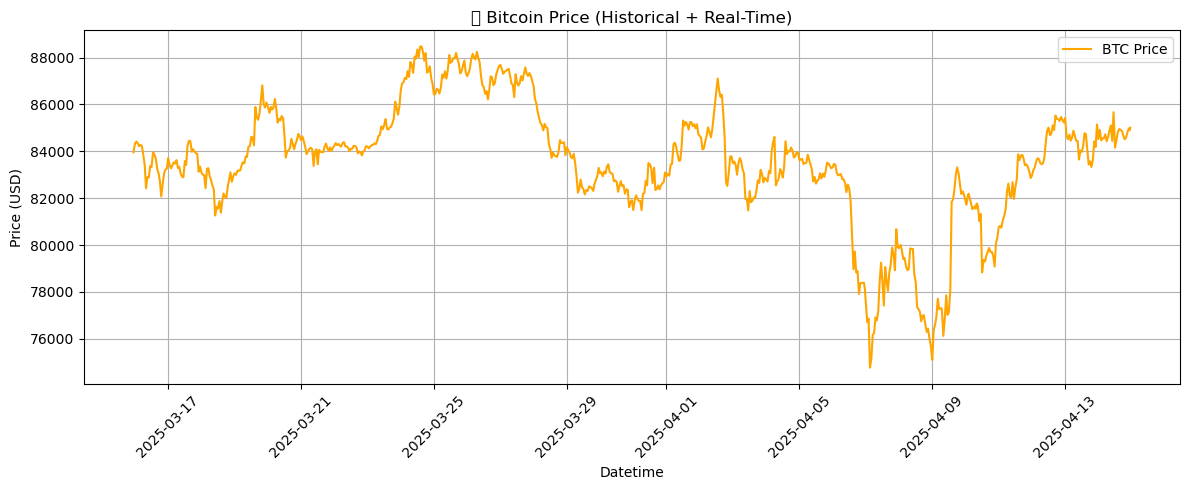

In [19]:
plt.figure(figsize=(12, 5))
plt.plot(combined_df["datetime"], combined_df["price_usd"], label="BTC Price", color="orange")
plt.title("📈 Bitcoin Price (Historical + Real-Time)")
plt.xlabel("Datetime")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/yw/7nv526h96y59_0vhdnlch9k80000gn/T/ipykernel_90994/1848926938.py:12: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


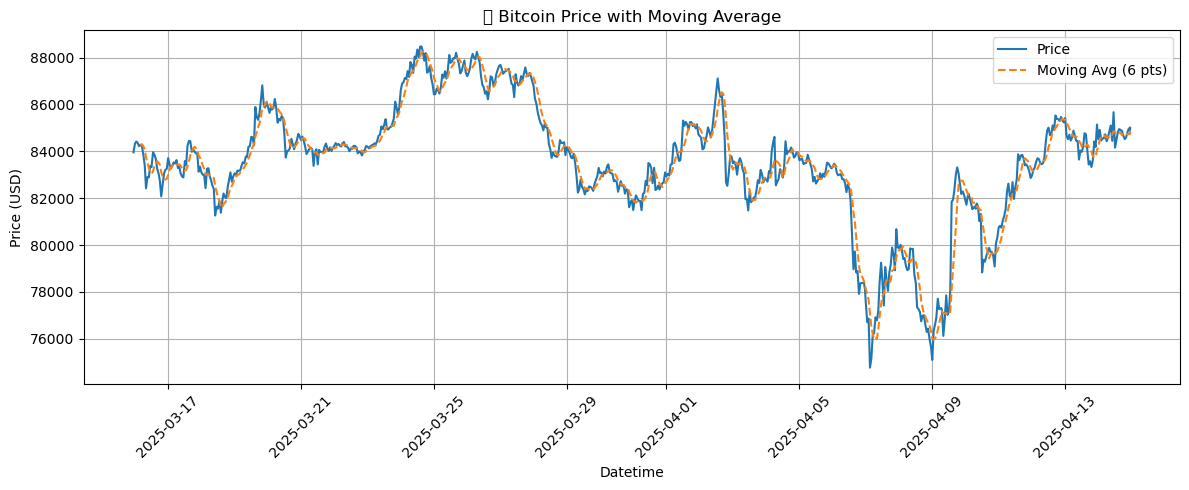

In [12]:
combined_df["price_ma"] = combined_df["price_usd"].rolling(window=6).mean()

plt.figure(figsize=(12, 5))
plt.plot(combined_df["datetime"], combined_df["price_usd"], label="Price")
plt.plot(combined_df["datetime"], combined_df["price_ma"], label="Moving Avg (6 pts)", linestyle="--")
plt.title("📊 Bitcoin Price with Moving Average")
plt.xlabel("Datetime")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
# Filter last 24 hours
cutoff = combined_df["datetime"].max() - pd.Timedelta(hours=24)
df_24h = combined_df[combined_df["datetime"] >= cutoff].copy()

# Set datetime as index for resampling
df_24h.set_index("datetime", inplace=True)

# Resample to hourly (mean price, total volume)
hourly_df = df_24h.resample("1H").agg({
    "price_usd": "mean",
    "volume_24h": "sum",
    "market_cap": "mean"
}).dropna()

hourly_df.reset_index(inplace=True)
print(f"🕒 Hourly records (last 24h): {len(hourly_df)}")
hourly_df.tail()

🕒 Hourly records (last 24h): 25


/var/folders/yw/7nv526h96y59_0vhdnlch9k80000gn/T/ipykernel_90994/1122664940.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = df_24h.resample("1H").agg({


,datetime,price_usd,volume_24h,market_cap
20,2025-04-14 19:00:00,84516.572276,3.347249e+10,1.678082e+12
21,2025-04-14 20:00:00,84590.220559,3.330183e+10,1.678629e+12
22,2025-04-14 21:00:00,84805.406235,3.230229e+10,1.683444e+12
23,2025-04-14 22:00:00,84940.807550,5.929824e+10,1.686237e+12
24,2025-04-14 23:00:00,85008.000000,5.988064e+10,1.686701e+12


/var/folders/yw/7nv526h96y59_0vhdnlch9k80000gn/T/ipykernel_90994/2438709609.py:8: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


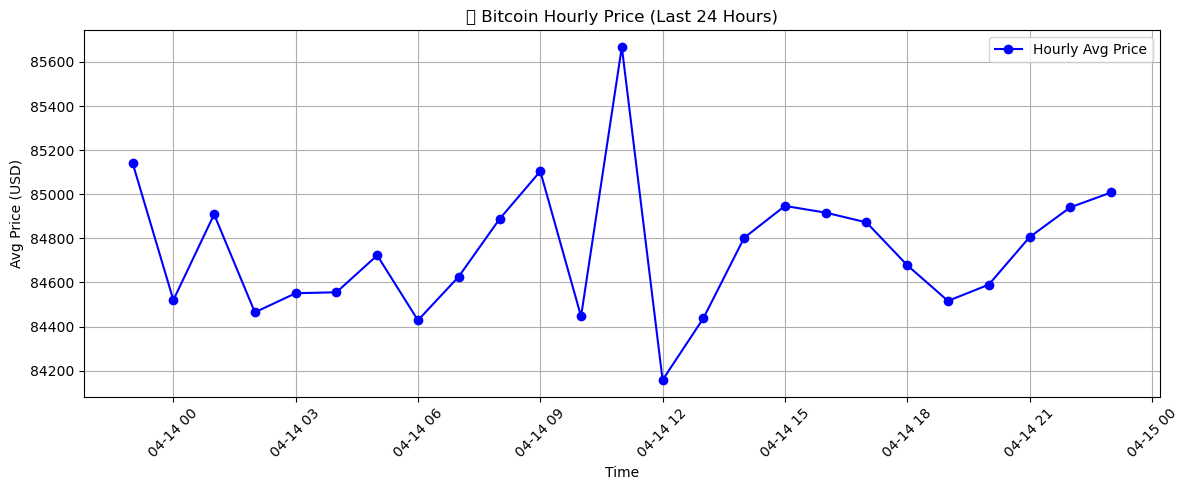

In [14]:
plt.figure(figsize=(12, 5))
plt.plot(hourly_df["datetime"], hourly_df["price_usd"], marker="o", label="Hourly Avg Price", color="blue")
plt.title("📉 Bitcoin Hourly Price (Last 24 Hours)")
plt.xlabel("Time")
plt.ylabel("Avg Price (USD)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/yw/7nv526h96y59_0vhdnlch9k80000gn/T/ipykernel_90994/4214285803.py:8: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


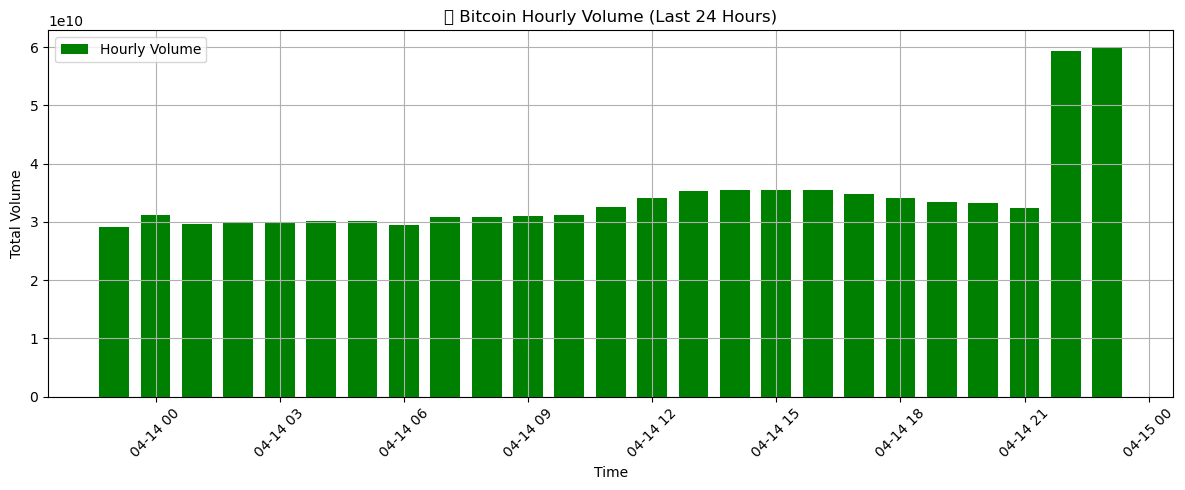

In [21]:
plt.figure(figsize=(12, 5))
plt.bar(hourly_df["datetime"], hourly_df["volume_24h"], width=0.03, label="Hourly Volume", color="green")
plt.title("📊 Bitcoin Hourly Volume (Last 24 Hours)")
plt.xlabel("Time")
plt.ylabel("Total Volume")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()